In [1]:
import numpy as np

In [2]:
# K-Means algorithm

class KMeans:
    
    def __init__(self, k):
        self.k = k
        self.centroids = None
        self.dimension = None

    def initialize_centroids(self, data):
        N = data.shape[0]
        
        # Select the first centroid randomly
        centroids = [data[np.random.randint(0, N)]]
        
        # Select remaining centroids
        for _ in range(1, self.k):
            # Compute distances from the nearest existing centroid
            distances = self._euclidean_distance(data, np.array(centroids))
            
            # Choose the next centroid with a probability proportional to the distance squared
            next_centroid_idx = np.argmax(np.min(distances, axis=1))
            centroids.append(data[next_centroid_idx])
        
        return np.array(centroids)

    def fit(self, data, max_iter=100):
        N, d = data.shape
        assert N >= self.k
        self.dimension = d

        # Initialize centroids using KMeans++
        self.centroids = self.initialize_centroids(data)
        # self.centroids = data[:self.k]
        
        for counter in range(max_iter):
            # Assign each data point to the nearest centroid
            assignment = self.transform(data)
            
            # Re-calculate centroids
            new_centroids = np.zeros(self.centroids.shape)
            for j in range(self.k):
                points_in_cluster = data[assignment == j]
                if len(points_in_cluster) != 0:
                    new_centroids[j] = points_in_cluster.mean(axis=0)
                else:
                    new_centroids[j] = data[np.random.randint(0, N)]
            
            # Check for convergence
            if np.allclose(self.centroids, new_centroids):
                print(f'Converged in {counter} iterations...')
                break
            self.centroids = new_centroids

    def transform(self, data):
        if self.dimension is None:
            print("Run fit() first")
            return
        distances = self._euclidean_distance(data, self.centroids)
        return np.argmin(distances, axis=1)
    
    def _euclidean_distance(self, a, b):
        N, M = a.shape[0], b.shape[0]
        distance = np.zeros((N, M))
        for i in range(N):
            distance[i] = np.sum((a[i] - b) ** 2, axis=1)
        
        return distance

Converged in 8 iterations...


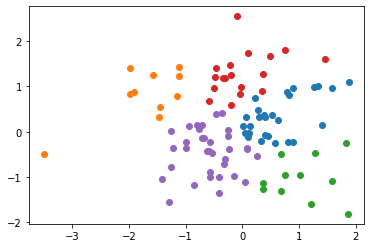

In [3]:
import matplotlib.pyplot as plt


data = np.random.randn(100, 2)
k = 5
kmeans = KMeans(k)
kmeans.fit(data)
assignment = kmeans.transform(data)

plt.figure()
for i in range(k):
    points = data[assignment==i]
    plt.scatter(points[:, 0], points[:, 1])
plt.show()

In [4]:
# linear regression


class LinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Number of training examples and features
        n_samples, n_features = X.shape
        
        # Initialize weights and bias to zero
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient Descent
        for _ in range(self.iterations):
            # Prediction (y_hat)
            y_pred = np.dot(X, self.weights) + self.bias
            
            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [5]:
# Example usage:

# Generate some dummy data (y = 2x + 3 + noise)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Reshape y for consistency
y = y.flatten()

# Initialize and train the model
regressor = LinearRegression(learning_rate=0.01, iterations=1000)
regressor.fit(X, y)

# Make predictions
X_test = np.array([[0], [2]])
predictions = regressor.predict(X_test)

print("Predictions:", predictions)

Predictions: [4.03321421 9.89462472]


In [6]:
# logistic regression

import numpy as np

class LogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    # Sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Fit the model using gradient descent
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters (weights and bias)
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent
        for _ in range(self.iterations):
            # Linear model
            linear_model = np.dot(X, self.weights) + self.bias
            # Apply sigmoid to get probabilities
            y_pred = self.sigmoid(linear_model)

            # Compute the gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    # Predict probability
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    # Predict binary labels (0 or 1)
    def predict(self, X, threshold=0.5):
        y_pred_proba = self.predict_proba(X)
        return [1 if i > threshold else 0 for i in y_pred_proba]

In [7]:
# Example usage:

# Generate some dummy data for binary classification
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # Features (100 samples, 1 feature)
y = (X[:, 0] > 5).astype(int)     # Labels (1 if X > 5, else 0)

# Initialize and train the model
log_reg = LogisticRegression(learning_rate=0.01, iterations=1000)
log_reg.fit(X, y)

# Make predictions
X_test = np.array([[3], [7]])
predictions = log_reg.predict(X_test)

print("Predictions:", predictions)

Predictions: [0, 1]


# decision tree


Here is how to implement a Decision Tree Classifier from scratch in Python. This implementation covers the basic ideas behind decision trees, including:

- Recursive Splitting: Dividing the data into smaller subsets based on the best splitting criterion.
- Gini Impurity: A measure of how often a randomly chosen element from the set would be incorrectly classified.
- Stopping Criteria: Based on maximum depth or when a node becomes pure (all data points have the same label).

In [8]:
import numpy as np

# Helper function to calculate Gini Impurity
def gini(y):
    """Calculate Gini Impurity for a node."""
    unique_classes, counts = np.unique(y, return_counts=True)
    prob_sq = np.sum((counts / len(y)) ** 2)
    return 1 - prob_sq

# Helper function to split the dataset
def split_dataset(X, y, feature_index, threshold):
    """Split the dataset into two parts based on a feature and a threshold."""
    left_idx = np.where(X[:, feature_index] <= threshold)[0]
    right_idx = np.where(X[:, feature_index] > threshold)[0]
    return X[left_idx], X[right_idx], y[left_idx], y[right_idx]

# Node class for constructing the tree
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index  # Index of feature used for splitting
        self.threshold = threshold          # Threshold value for the split
        self.left = left                    # Left subtree
        self.right = right                  # Right subtree
        self.value = value                  # Leaf node value (for predictions)

# Decision Tree Classifier
class DecisionTreeClassifier:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    
    # Fit the model
    def fit(self, X, y):
        """Build the tree by recursively splitting nodes."""
        self.root = self._build_tree(X, y, depth=0)
    
    # Build the tree recursively
    def _build_tree(self, X, y, depth):
        """Recursively build the decision tree."""
        num_samples, num_features = X.shape
        # Stopping conditions
        if depth >= self.max_depth or num_samples < self.min_samples_split or len(np.unique(y)) == 1:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Find the best split
        best_feature, best_threshold = self._find_best_split(X, y, num_features)
        
        # Split the dataset
        X_left, X_right, y_left, y_right = split_dataset(X, y, best_feature, best_threshold)
        
        # If the split doesn't divide the dataset, return a leaf
        if len(y_left) == 0 or len(y_right) == 0:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        # Create left and right subtrees
        left_subtree = self._build_tree(X_left, y_left, depth + 1)
        right_subtree = self._build_tree(X_right, y_right, depth + 1)
        return Node(best_feature, best_threshold, left_subtree, right_subtree)

    # Find the best feature and threshold to split on
    def _find_best_split(self, X, y, num_features):
        """Find the best split by iterating over all features and all unique thresholds."""
        best_gini = float('inf')  # Start with the worst Gini score
        best_feature, best_threshold = None, None
        
        for feature_index in range(num_features):
            feature_values = X[:, feature_index]
            possible_thresholds = np.unique(feature_values)
            
            # Test each threshold as a potential split
            for threshold in possible_thresholds:
                _, _, y_left, y_right = split_dataset(X, y, feature_index, threshold)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                
                gini_score = self._calculate_gini(y_left, y_right)
                
                # Check if this split has the best (lowest) Gini score
                if gini_score < best_gini:
                    best_gini = gini_score
                    best_feature = feature_index
                    best_threshold = threshold
        
        return best_feature, best_threshold
    
    # Calculate Gini score after a split
    def _calculate_gini(self, y_left, y_right):
        """Calculate the Gini Impurity after splitting the dataset."""
        left_size = len(y_left)
        right_size = len(y_right)
        total_size = left_size + right_size
        gini_left = gini(y_left)
        gini_right = gini(y_right)
        weighted_gini = (left_size / total_size) * gini_left + (right_size / total_size) * gini_right
        return weighted_gini

    # Most common label for a leaf node
    def _most_common_label(self, y):
        """Return the most common label in a node (used for leaf nodes)."""
        unique_classes, counts = np.unique(y, return_counts=True)
        most_common = unique_classes[np.argmax(counts)]
        return most_common

    # Predict for a single sample
    def _predict_sample(self, node, sample):
        """Recursively traverse the tree to make a prediction for a single sample."""
        if node.value is not None:
            return node.value
        if sample[node.feature_index] <= node.threshold:
            return self._predict_sample(node.left, sample)
        else:
            return self._predict_sample(node.right, sample)
    
    # Predict for the entire dataset
    def predict(self, X):
        """Predict the class labels for the input data."""
        return [self._predict_sample(self.root, sample) for sample in X]

In [9]:
# Example usage

# Generate some simple data (XOR problem)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Initialize and fit the decision tree
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

# Test the tree's prediction
X_test = np.array([[0, 1], [1, 1]])
predictions = tree.predict(X_test)

print("Predictions:", predictions)

Predictions: [1, 0]
